##  Fase #3 - Modelos de Regresión - RandomForest

#### 1. Import Necesarios

In [50]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from matplotlib import pyplot as plt

#### 2. Carga del dataset limpio

In [51]:
df = pd.read_csv('../data/avocado_clean.csv')
print("Dataset cargado:")
print(df.shape)
print(df.dtypes)

Dataset cargado:
(17934, 65)
Date                           str
AveragePrice               float64
Total Volume               float64
4046                       float64
4225                       float64
                            ...   
region_SYRACUSE            float64
region_TAMPA               float64
region_TOTALUS             float64
region_WEST                float64
region_WESTTEXNEWMEXICO    float64
Length: 65, dtype: object


#### 3. Crear Variables de entrenamiento y prueba

In [52]:
# Convertir Date a datetime primero
df_model = df.copy()
df_model['Date'] = pd.to_datetime(df_model['Date'])

# Extraer componentes temporales
df_model['month'] = df_model['Date'].dt.month
df_model['week']  = df_model['Date'].dt.isocalendar().week.astype(int)
df_model = df_model.drop(columns=['Date'])

# Separar features y variable objetivo
X = df_model.drop(columns=['AveragePrice'])
y = df_model['AveragePrice']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (14347, 65) | Test: (3587, 65)


#### 4. Modelo Entrenado
Se usa un valor de 100 arboles distintos para entrenar el modelo distribuidos en todos los núcleos del computador para poder ejecutarlos en paralelo, estos sin un límite de profundidad, ya que, no afecta a los valores obtenidos (en especial al R²) mostrados al final de la ejecución

In [53]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf  = r2_score(y_test, y_pred_rf)

print("── Random Forest ────────")
print(f"  MSE:  {mse_rf:.4f}")
print(f"  MAE:  {mae_rf:.4f}")
print(f"  R²:   {r2_rf:.4f}")

── Random Forest ────────
  MSE:  0.0966
  MAE:  0.2182
  R²:   0.9043


El modelo Random Forest con variables temporales es el mejor resultado del proyecto. Un R²=0.9043 significa que el modelo explica el 90.4% de la variación en el precio del aguacate, lo cual es considerado excelente para datos de precios agrícolas donde intervienen factores externos no capturados (clima, cosecha, importaciones).

#### 5. Gráfica de las columnas más importantes

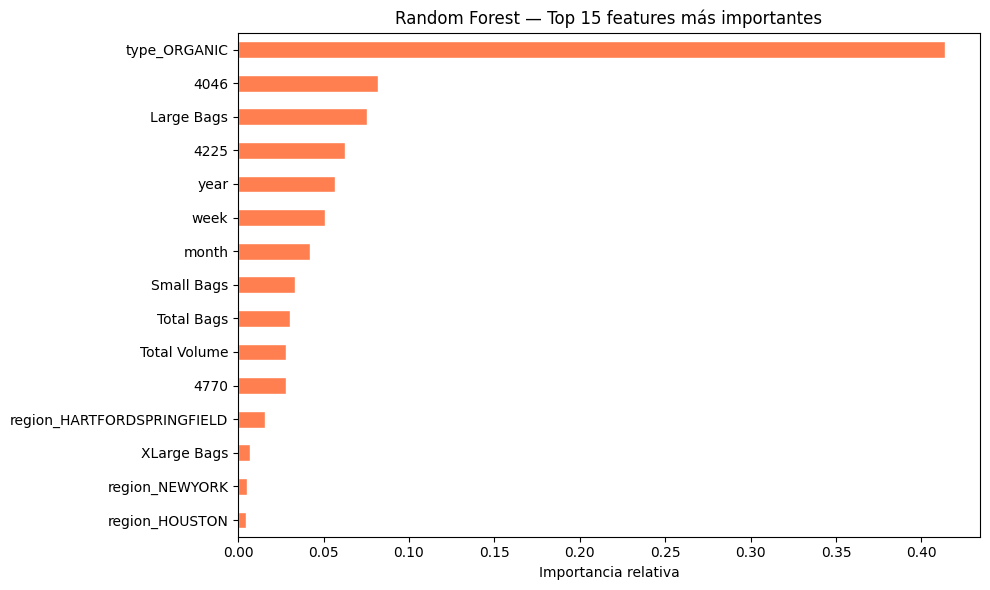

In [54]:
importancias = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importancias.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top_features.plot(kind='barh', ax=ax, color='coral', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Random Forest — Top 15 features más importantes')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.savefig('rf_importancia_features.png', dpi=150, bbox_inches='tight')
plt.show()

´type_ORGANIC´ es por lejos el factor más determinante del precio del aguacate, con una importancia de ~0.42, siendo más del doble que todas las demás variables combinadas en el top 5. 

Le siguen los volúmenes de venta por tipo de PLU (4046, 4225) y por formato de bolsa (Large Bags, Small Bags). 

Las fechas indican que los aguacates tienen un componente real estacionario, indicando que por temporadas puede incrementar o disminuir el precio.

Las variables de región tienen influencia mínima individualmente, lo que sugiere que el tipo de aguacate explica las diferencias de precio mejor que la ubicación geográfica.

#### 6. Gráficas de análisis
Se grafican distintas formas de mostrar la distribucipon de los valores reales y predichos por medio de comparaticas directas y visualización de la fistribución de errores

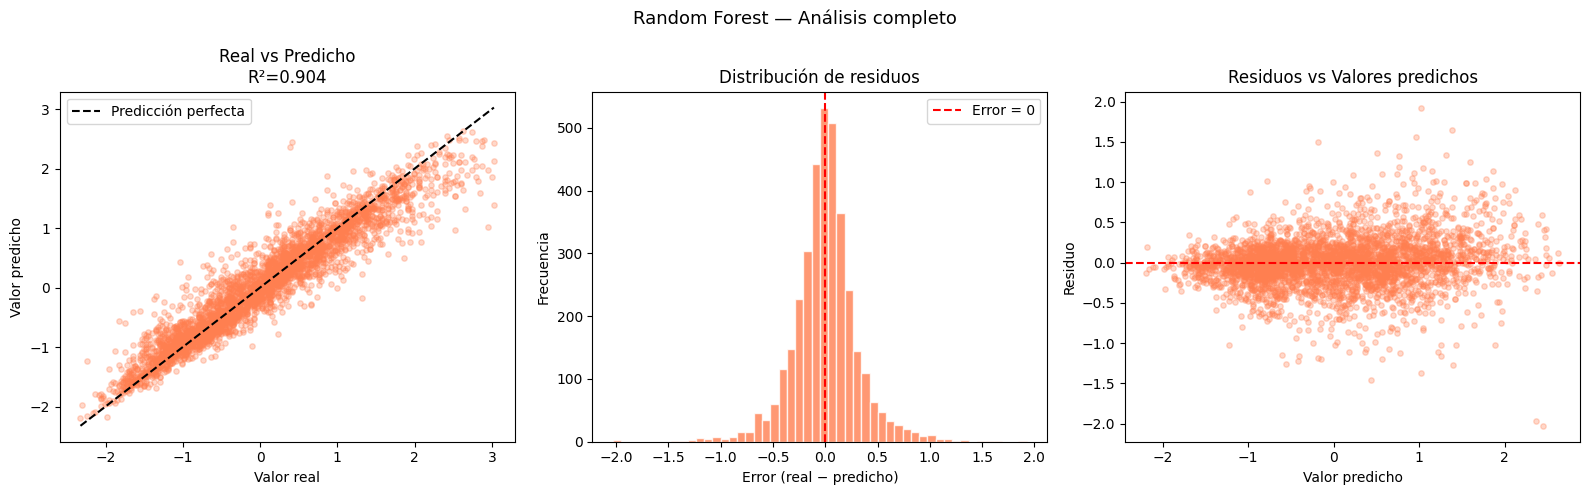

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Real vs Predicho
axes[0].scatter(y_test, y_pred_rf, alpha=0.3, s=15, color='coral')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'k--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_title(f'Real vs Predicho\nR²={r2_rf:.3f}')
axes[0].set_xlabel('Valor real')
axes[0].set_ylabel('Valor predicho')
axes[0].legend()

# 2. Distribución de residuos
residuos_rf = y_test - y_pred_rf
axes[1].hist(residuos_rf, bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linewidth=1.5, linestyle='--', label='Error = 0')
axes[1].set_title('Distribución de residuos')
axes[1].set_xlabel('Error (real − predicho)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

# 3. Residuos vs Predichos
axes[2].scatter(y_pred_rf, residuos_rf, alpha=0.3, s=15, color='coral')
axes[2].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[2].set_title('Residuos vs Valores predichos')
axes[2].set_xlabel('Valor predicho')
axes[2].set_ylabel('Residuo')

plt.suptitle('Random Forest — Análisis completo', fontsize=13)
plt.tight_layout()
plt.savefig('rf_analisis_completo.png', dpi=150, bbox_inches='tight')
plt.show()

Para la gráfica de los valores reales contra los predichos con R²=0.853, el modelo Random Forest predice el precio del aguacate con alta precisión. La mayoría de los puntos se concentran sobre la línea de predicción perfecta (diagonal punteada), especialmente en el rango central.

 La dispersión aumenta en los extremos, los cuales son los precios muy bajos o muy altos que son ligeramente más difíciles de predecir, lo cual es un comportamiento esperado en cualquier modelo de regresión sobre datos de precios agrícolas.

 ---

 La gráfica de distribución de residuos muestra una campana estrecha, casi perfectamente centrada en 0, lo que significa dos cosas: el modelo no sobreestima ni subestima sistemáticamente, y los errores son aleatorios, cometiendo errores más pequeños y más consistentes.
 
La cola larga hacia la derecha indica que ocasionalmente el modelo subestima precios muy altos, lo que ya se veía en la dispersión en los extremos de la primera gráfica.

 ---

en la gráfica de residuos contra los valores predichos se muestra la prueba de que el modelo no tiene problemas estructurales. Si hubiera un patrón como abanico o curva  significaría que el modelo falla sistemáticamente en cierto rango de precios.

 Aquí los puntos forman una nube aleatoria uniforme alrededor de la línea roja (error=0) en todo el eje horizontal, lo que confirma que los errores son aleatorios e independientes del valor predicho. Esto es exactamente lo que se busca en un buen modelo de regresión.

#### 7. Estructura de árboles generados

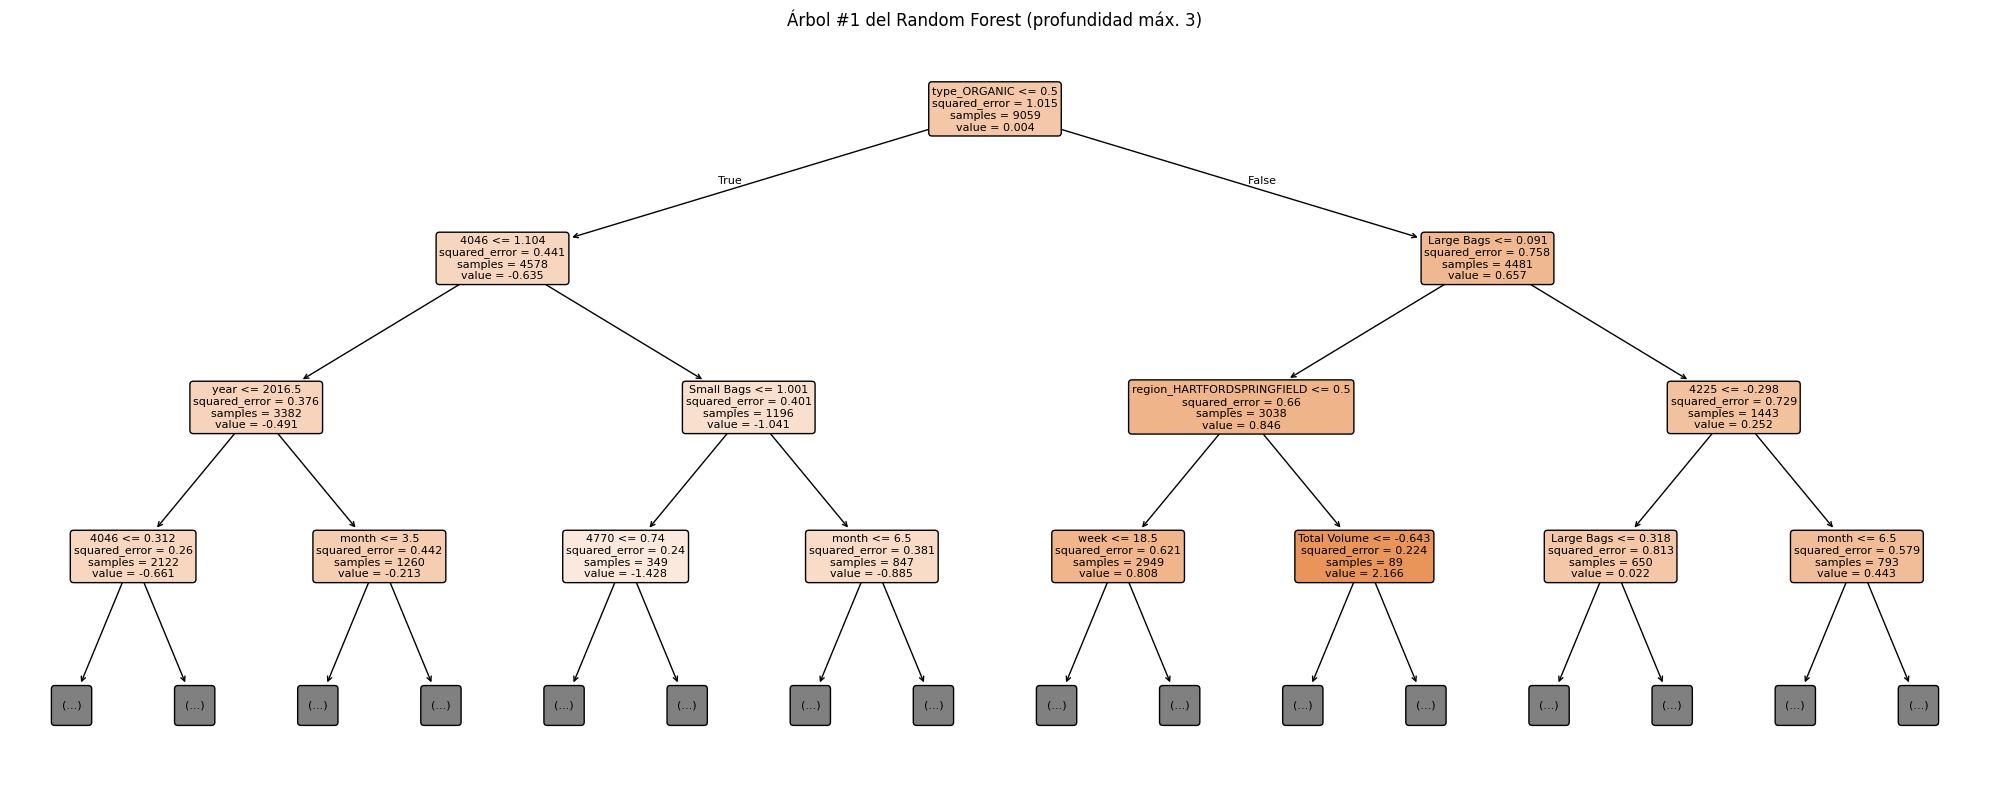

In [56]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    rf.estimators_[0],
    feature_names=X.columns,
    max_depth=3,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax
)
ax.set_title('Árbol #1 del Random Forest (profundidad máx. 3)')
plt.tight_layout()
plt.savefig('rf_arbol_ejemplo.png', dpi=150, bbox_inches='tight')
plt.show()

Este árbol ilustra la lógica de decisión que aplica uno de los 100 árboles del modelo, la primera división siempre es type_ORGANIC: si es orgánico (False, derecha) el precio predicho sube inmediatamente a 0.657, si es convencional (True, izquierda) baja a -0.635. 

A partir de ahí el árbol refina la predicción usando volúmenes de venta (4046, Large Bags, Small Bags) y variables de región. Esto confirma visualmente por qué type_ORGANIC es la feature más importante del modelo.